In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q opencv-python matplotlib tqdm pycocotools

In [2]:
import os
import cv2
import glob
import zipfile
import urllib.request
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane", "bus",
    "train", "truck", "boat", "traffic light", "fire hydrant", "stop sign",
    "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag",
    "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite",
    "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana",
    "apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed", "dining table",
    "toilet", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock",
    "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

In [5]:
import os, zipfile, urllib.request

DAVIS_URL = "https://data.vision.ee.ethz.ch/csergi/share/davis/DAVIS-2017-trainval-480p.zip"
DATA_ROOT = "/content/DAVIS"

os.makedirs(DATA_ROOT, exist_ok=True)
zip_path = os.path.join(DATA_ROOT, "davis.zip")

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(DAVIS_URL, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(DATA_ROOT)

print("DAVIS dataset ready")

DAVIS dataset ready


In [6]:
def mask_to_boxes(mask):
    boxes = []
    ids = np.unique(mask)

    for obj_id in ids:
        if obj_id == 0:
            continue
        binary = (mask == obj_id).astype(np.uint8)
        y, x = np.where(binary)
        if len(x) == 0:
            continue
        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()

        # Ensure positive width and height
        if xmax > xmin and ymax > ymin:
            boxes.append([xmin, ymin, xmax, ymax])

    return boxes

In [7]:
class DAVISDetection(Dataset):
    def __init__(self, root):
        self.imgs = sorted(glob.glob(root + "/DAVIS/JPEGImages/480p/*/*.jpg"))
        self.masks = sorted(glob.glob(root + "/DAVIS/Annotations/480p/*/*.png"))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = cv2.imread(self.imgs[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], 0)
        boxes = mask_to_boxes(mask)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.full(
                (len(boxes),),
                fill_value=1,  # generic foreground
                dtype=torch.int64
            )
        }

        img = F.to_tensor(img)
        return img, target

In [8]:
dataset = DAVISDetection(DATA_ROOT)

def collate_fn(batch):
    return tuple(zip(*batch))

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

In [9]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

model = fasterrcnn_resnet50_fpn(
    weights="DEFAULT"  # COCO pretrained
)

model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 179MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [10]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)


In [ ]:
model.train()

for epoch in range(5):
    epoch_loss = 0
    for original_imgs, original_targets in tqdm(loader):
        original_imgs = [img.to(device) for img in original_imgs]
        original_targets = [{k: v.to(device) for k, v in t.items()} for t in original_targets]
        filtered_imgs = []
        filtered_targets = []
        for img, target in zip(original_imgs, original_targets):
            if target["boxes"].numel() > 0:
                filtered_imgs.append(img)
                filtered_targets.append(target)

        if not filtered_imgs:
            print(f"Skipping batch in Epoch {epoch+1} as no ground truth objects were found.")
            continue

        loss_dict = model(filtered_imgs, filtered_targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {epoch_loss/len(loader):.4f}")

100%|██████████| 3104/3104 [30:51<00:00,  1.68it/s]


Epoch 1 | Loss: 0.1778


 14%|█▍        | 433/3104 [04:18<25:33,  1.74it/s]

Skipping batch in Epoch 2 as no ground truth objects were found.


100%|██████████| 3104/3104 [30:50<00:00,  1.68it/s]


...

Epoch 3 | Loss: 0.1035


100%|██████████| 3104/3104 [30:53<00:00,  1.67it/s]


Epoch 4 | Loss: 0.0971


100%|██████████| 3104/3104 [30:54<00:00,  1.67it/s]

Epoch 5 | Loss: 0.0955


In [ ]:
torch.save(model.state_dict(), 'fasterrcnn_davis.pth')
print("Model saved to fasterrcnn_davis.pth")

Model saved to fasterrcnn_davis.pth


In [11]:
def load_split(split):
    split_file = f"{DATA_ROOT}/DAVIS/ImageSets/2017/{split}.txt"
    with open(split_file) as f:
        seqs = f.read().splitlines()

    imgs, masks = [], []
    for s in seqs:
        imgs += sorted(glob.glob(f"{DATA_ROOT}/DAVIS/JPEGImages/480p/{s}/*.jpg"))
        masks += sorted(glob.glob(f"{DATA_ROOT}/DAVIS/Annotations/480p/{s}/*.png"))

    return imgs, masks

In [12]:
class DAVISTest(Dataset):
    def __init__(self, imgs, masks):
        self.imgs = imgs
        self.masks = masks

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = cv2.imread(self.imgs[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks[idx], 0)

        gt_boxes = mask_to_boxes(mask)
        img = F.to_tensor(img)
        return img, gt_boxes

In [13]:
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    union = ((boxA[2]-boxA[0])*(boxA[3]-boxA[1]) +
             (boxB[2]-boxB[0])*(boxB[3]-boxB[1]) - inter)
    return inter / (union + 1e-6)

def compute_f1(tp, fp, fn):
    p = tp / (tp + fp + 1e-6)
    r = tp / (tp + fn + 1e-6)
    f1 = 2*p*r / (p+r+1e-6)
    return p, r, f1

In [ ]:
val_imgs, val_masks = load_split("val")
test_ds = DAVISTest(val_imgs, val_masks)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

model.eval()
TP = FP = FN = 0
ious = []

with torch.no_grad():
    for img, gt_boxes in tqdm(test_loader):
        img = img.to(device)
        # Fix: Remove the batch dimension before passing to the model
        pred = model([img.squeeze(0)])[0]

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        boxes = boxes[scores > 0.7]

        matched = set()
        for pb in boxes:
            ok = False
            # Convert gt_boxes to a list of numpy arrays for iou calculation
            current_gt_boxes = [np.array([coord.item() for coord in gb_coords]) for gb_coords in gt_boxes]
            for i, gb in enumerate(current_gt_boxes):
                if i not in matched and iou(pb, gb) > 0.5:
                    TP += 1
                    matched.add(i)
                    ious.append(iou(pb, gb))
                    ok = True
                    break
            if not ok:
                FP += 1
        FN += len(current_gt_boxes) - len(matched)

p, r, f1 = compute_f1(TP, FP, FN)
print(f"Precision: {p:.3f}, Recall: {r:.3f}, F1: {f1:.3f}")
print(f"Mean IoU: {np.mean(ious):.3f}")

100%|██████████| 1999/1999 [04:40<00:00,  7.13it/s]

Precision: 0.966, Recall: 0.969, F1: 0.968
Mean IoU: 0.912


### Load Saved Model for Evaluation

In [14]:
model_path = input("Enter the path to your saved model file (e.g., fasterrcnn_davis.pth): ")

if os.path.exists(model_path):
    # Initialize the model with the same architecture
    loaded_model = fasterrcnn_resnet50_fpn(
        weights=None  # Do not load pretrained weights initially
    )

    # Load the state dictionary
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.to(device)
    loaded_model.eval()

    print(f"Model loaded from {model_path} and set to evaluation mode.")
else:
    print(f"Error: Model file not found at {model_path}. Please provide a valid path.")

Enter the path to your saved model file (e.g., fasterrcnn_davis.pth): /content/fasterrcnn_davis_updated.pth
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


Model loaded from /content/fasterrcnn_davis_updated.pth and set to evaluation mode.


### Evaluate Loaded Model

In [15]:
val_imgs, val_masks = load_split("val")
test_ds = DAVISTest(val_imgs, val_masks)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

TP = FP = FN = 0
ious = []

with torch.no_grad():
    for img, gt_boxes in tqdm(test_loader):
        img = img.to(device)
        pred = loaded_model([img.squeeze(0)])[0]

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        boxes = boxes[scores > 0.7]

        matched = set()
        for pb in boxes:
            ok = False
            current_gt_boxes = [np.array([coord.item() for coord in gb_coords]) for gb_coords in gt_boxes]
            for i, gb in enumerate(current_gt_boxes):
                if i not in matched and iou(pb, gb) > 0.5:
                    TP += 1
                    matched.add(i)
                    ious.append(iou(pb, gb))
                    ok = True
                    break
            if not ok:
                FP += 1
        FN += len(current_gt_boxes) - len(matched)

p, r, f1 = compute_f1(TP, FP, FN)
print(f"Precision: {p:.3f}, Recall: {r:.3f}, F1: {f1:.3f}")
print(f"Mean IoU: {np.mean(ious):.3f}")

100%|██████████| 1999/1999 [04:43<00:00,  7.05it/s]

Precision: 0.967, Recall: 0.969, F1: 0.968
Mean IoU: 0.912


In [16]:
def eval_image_with_classification(path, score_thr=0.7):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = F.to_tensor(img).to(device)

    model.eval()
    with torch.no_grad():
        pred = model([t])[0]

    for box, score, label in zip(
        pred["boxes"], pred["scores"], pred["labels"]
    ):
        if score > score_thr:
            x1,y1,x2,y2 = map(int, box)
            class_name = COCO_CLASSES[label]

            cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.putText(
                img,
                f"{class_name} {score:.2f}",
                (x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,0),
                2
            )

    plt.imshow(img)
    plt.axis("off")


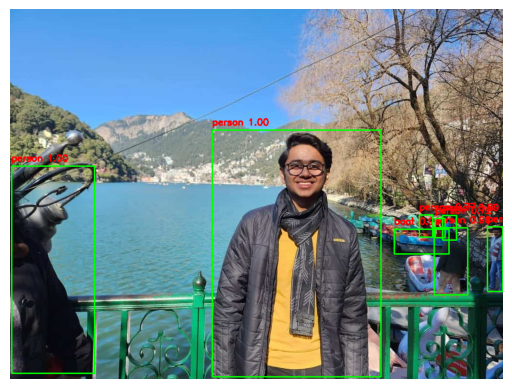

In [26]:
eval_image_with_classification("/content/20231231_111335-min-min (1)-min.jpg")

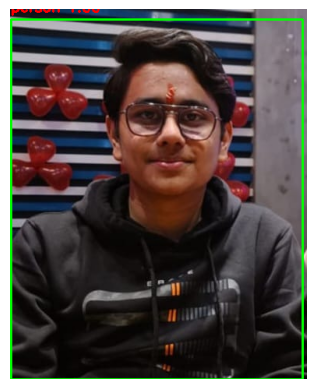

In [27]:
eval_image_with_classification("/content/WhatsApp Image 2025-05-22 at 15.15.12_ec06378b.jpg")

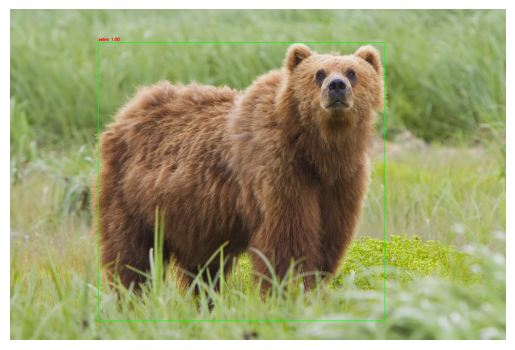

In [28]:
eval_image_with_classification("/content/2010-kodiak-bear-1.jpg")

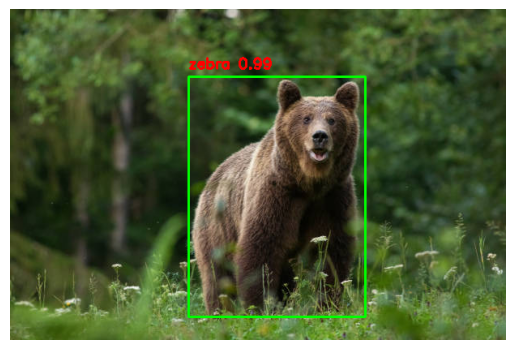

In [29]:
eval_image_with_classification("/content/istockphoto-1017220160-612x612.jpg")

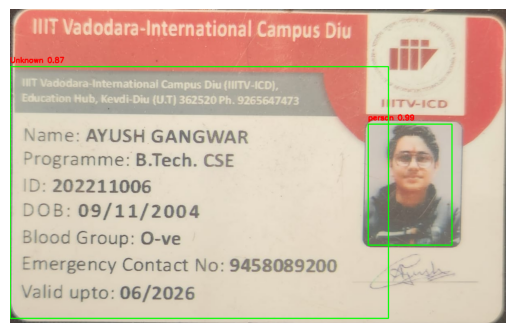

In [33]:
def eval_image_with_classification(path, score_thr=0.7):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = F.to_tensor(img).to(device)

    model.eval()
    with torch.no_grad():
        pred = model([t])[0]

    for box, score, label in zip(
        pred["boxes"], pred["scores"], pred["labels"]
    ):
        if score > score_thr:
            x1,y1,x2,y2 = map(int, box)
            if label < len(COCO_CLASSES):
                class_name = COCO_CLASSES[label]
            else:
                class_name = "Unknown"

            cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.putText(
                img,
                f"{class_name} {score:.2f}",
                (x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,0),
                2
            )

    plt.imshow(img)
    plt.axis("off")

eval_image_with_classification("/content/ID_card.jpg")

In [ ]:
eval_image_with_classification("/content/20231231_084320.jpg")

In [36]:
def eval_video_with_classification(video_path, output="output.mp4", score_thr=0.7):
    cap = cv2.VideoCapture(video_path)
    w,h = int(cap.get(3)), int(cap.get(4))
    fps = cap.get(cv2.CAP_PROP_FPS)

    out = cv2.VideoWriter(
        output,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w,h)
    )

    model.eval()
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        t = F.to_tensor(img).to(device)

        with torch.no_grad():
            pred = model([t])[0]

        for box, score, label in zip(
            pred["boxes"], pred["scores"], pred["labels"]
        ):
            if score > score_thr:
                x1,y1,x2,y2 = map(int, box)
                if label < len(COCO_CLASSES):
                    class_name = COCO_CLASSES[label]
                else:
                    class_name = "Unknown" # Handle out-of-range labels

                cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)
                cv2.putText(
                    frame,
                    f"{class_name} {score:.2f}",
                    (x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255,0,0),
                    2
                )

        out.write(frame)

    cap.release()
    out.release()
    print("Saved video:", output)

In [37]:
eval_video_with_classification("/content/457701_Asia_Korea_3840x2160.mp4")

Saved video: output.mp4
